# PortfolioOptimizer 对比教程

在 `rotation_strategy` 教程中，我们学习了如何用 TopNRankingOptimizer 构建轮动策略。但 TopNRankingOptimizer 只是 open-xquant 提供的多种 **PortfolioOptimizer** 之一。

本教程对比三种 PortfolioOptimizer 在相同条件下的表现差异：

| 优化器 | 核心思路 | 适用场景 |
|------|----------|----------|
| **EqualWeightOptimizer** | 所有资产等权分配 | 没有明确观点，追求分散化 |
| **TopNRankingOptimizer** | 按评分排名，优选 Top N | 对动量/因子有信心，愿意集中持仓 |
| **RiskParityOptimizer** | 按波动率倒数分配，低波动多配 | 追求风险均衡，不想被高波动资产主导 |

### 实验设计

**控制变量**：相同标的、相同日期、相同指标

**自变量**：PortfolioOptimizer 的权重分配方法

```
Universe    → 513100.SS, 510300.SS, 518880.SS
  ↓
Indicator   → mom = Momentum(20)
            → vol = RollingVolatility(20)
            → ram = Ratio(mom / vol)
  ↓
Signal      → Threshold(column=ram, threshold=0, relationship=gt)
  ↓
Portfolio   → ① EqualWeightOptimizer()
            → ② TopNRankingOptimizer(score_col=ram, n=2, max_weight=0.6)
            → ③ RiskParityOptimizer(volatility_col=vol)
```

### 前置条件

- 已完成 `rotation_strategy` 教程（了解 Indicator → Signal → PortfolioOptimizer 流程）
- 已下载数据（参考 `rotation_strategy` 教程第 1 节）

## 1. 准备数据与指标

In [1]:
import pandas as pd

from oxq.data import LocalMarketDataProvider
from oxq.indicators import Momentum, Ratio, RollingVolatility

SYMBOLS = ("513100.SS", "510300.SS", "518880.SS")
SYMBOL_NAMES = {
    "513100.SS": "纳指100ETF",
    "510300.SS": "沪深300ETF",
    "518880.SS": "黄金ETF",
}
START = "2024-11-15"
END = "2026-02-28"

# 加载行情 & 计算指标（与 rotation_strategy 教程完全相同）
market = LocalMarketDataProvider()
mktdata: dict[str, pd.DataFrame] = {}
for sym in SYMBOLS:
    d = market.get_bars(sym, START, END).copy()
    d["mom"] = Momentum().compute(d, column="close", period=20)
    d["vol"] = RollingVolatility().compute(d, column="close", period=20)
    d["ram"] = Ratio().compute(d, col_a="mom", col_b="vol")
    mktdata[sym] = d

print(f"标的: {', '.join(SYMBOL_NAMES[s] for s in SYMBOLS)}")
print(f"区间: {START} ~ {END}")
print(f"每只 ETF 含列: {list(mktdata[SYMBOLS[0]].columns)}")

标的: 纳指100ETF, 沪深300ETF, 黄金ETF
区间: 2024-11-15 ~ 2026-02-28
每只 ETF 含列: ['open', 'high', 'low', 'close', 'volume', 'mom', 'vol', 'ram']


## 2. 三种 PortfolioOptimizer 的算法对比

三种优化器都接收相同的输入 `signals: dict[str, DataFrame]` 和 `indicators: dict[str, DataFrame]`，返回相同的输出 `dict[str, float]`（每个 symbol 一个目标权重）。区别在于**如何计算权重**。

| | EqualWeightOptimizer | TopNRankingOptimizer | RiskParityOptimizer |
|---|---|---|---|
| **输入依赖** | 只需知道 symbol 列表 | 需要评分列（如 ram） | 需要波动率列（如 vol） |
| **筛选逻辑** | 全选 | 按评分取 Top N | 全选 |
| **权重计算** | 1/N 等分 | 评分归一化 | 波动率倒数归一化 |
| **隐含观点** | 无观点 | 动量越强越值得持有 | 波动越低越值得持有 |

### 2.1 EqualWeightOptimizer — 等权分配

最简单的权重方案：所有标的平均分配。

```
权重 = 1 / N（N 为标的数量）
```

**特点**：不需要任何指标输入，对所有资产一视同仁。适合作为 baseline 或在没有好的因子时使用。

In [ ]:
from oxq.portfolio.optimizers import EqualWeightOptimizer

ew_opt = EqualWeightOptimizer()
ew_weights = ew_opt.optimize(
    signals={s: mktdata[s] for s in SYMBOLS},
    indicators={s: mktdata[s] for s in SYMBOLS},
)

print("EqualWeightOptimizer 权重：")
for sym, w in ew_weights.items():
    name = SYMBOL_NAMES.get(sym, sym)
    print(f"  {name}: {w:.4f}")
print(f"\n每只 ETF 权重 = 1/{len(SYMBOLS)} = {1/len(SYMBOLS):.4f}")

### 2.2 TopNRankingOptimizer — 截面排名归一化

按评分（ram = 风险调整动量）排名，选 Top N 并按评分比例分配权重。

```
每个 bar:
  1. 读取每只标的的 score_col 列（如 ram）
  2. 过滤 NaN 和负值（动量为负 = 下跌趋势，不选）
  3. 按评分降序排名，取 Top N
  4. 权重 = score / sum(top_n_scores)（归一化到 1.0）
  5. 裁剪至 max_weight
```

**特点**：评分越高权重越大，主动集中到最强资产。适合对动量因子有信心的场景。

In [ ]:
from oxq.portfolio.optimizers import TopNRankingOptimizer

tn_opt = TopNRankingOptimizer(score_col="ram", n=2, max_weight=0.6)
tn_weights = tn_opt.optimize(
    signals={s: mktdata[s] for s in SYMBOLS},
    indicators={s: mktdata[s] for s in SYMBOLS},
)

print("TopNRankingOptimizer 权重（最后一个 bar）：")
for sym, w in tn_weights.items():
    name = SYMBOL_NAMES.get(sym, sym)
    print(f"  {name}: {w:.4f}")
print("\n注意：")
print("  - 最多只有 2 只 ETF 获得非零权重（n=2）")
print("  - 动量为负的标的被过滤，权重 = 0")
print("  - 权重按评分比例分配，不是简单等分")

### 2.3 RiskParityOptimizer — 风险平价

按波动率倒数分配权重——波动越低，配得越多。

```
每个 bar:
  1. 读取每只标的的 volatility_col 列
  2. 过滤零/负值
  3. 计算 inv_vol = 1 / vol
  4. 权重 = inv_vol / sum(inv_vol)（归一化到 1.0）
```

**特点**：低波动资产获得更高权重，使得每只资产对组合的风险贡献大致相等。适合追求风险均衡的场景。

In [ ]:
from oxq.portfolio.optimizers import RiskParityOptimizer

rp_opt = RiskParityOptimizer(volatility_col="vol")
rp_weights = rp_opt.optimize(
    signals={s: mktdata[s] for s in SYMBOLS},
    indicators={s: mktdata[s] for s in SYMBOLS},
)

print("RiskParityOptimizer 权重（最后一个 bar）：")
for sym, w in rp_weights.items():
    name = SYMBOL_NAMES.get(sym, sym)
    vol = float(mktdata[sym]["vol"].iloc[-1])
    print(f"  {name}: 权重={w:.4f}  (vol={vol:.4f})")
print("\n波动率最低的 ETF 获得最高权重")

---
## 3. 权重快照对比

PortfolioOptimizer 在每个 bar 计算目标权重。上面展示了最后一个 bar 的权重。
三种优化器对同一组资产的权重分配差异一目了然：
- EqualWeightOptimizer 等分
- TopNRankingOptimizer 集中在评分最高的标的
- RiskParityOptimizer 偏向低波动标的

In [ ]:
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

# 注册 macOS 系统中文字体，使 matplotlib 能正确渲染中文
for _font_path in [
    "/System/Library/Fonts/STHeiti Medium.ttc",
    "/System/Library/Fonts/STHeiti Light.ttc",
]:
    fm.fontManager.addfont(_font_path)
plt.rcParams["font.sans-serif"] = ["Heiti TC"] + plt.rcParams["font.sans-serif"]
plt.rcParams["axes.unicode_minus"] = False

names = [SYMBOL_NAMES[s] for s in SYMBOLS]
ew_vals = [ew_weights.get(s, 0) for s in SYMBOLS]
tn_vals = [tn_weights.get(s, 0) for s in SYMBOLS]
rp_vals = [rp_weights.get(s, 0) for s in SYMBOLS]

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
colors = ["#4C78A8", "#F58518", "#E45756"]

for ax, vals, title in zip(
    axes,
    [ew_vals, tn_vals, rp_vals],
    ["EqualWeightOptimizer", "TopNRankingOptimizer", "RiskParityOptimizer"],
):
    bars = ax.bar(names, vals, color=colors, width=0.6)
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_ylim(0, 0.7)
    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            val + 0.02,
            f"{val:.2%}",
            ha="center",
            fontsize=10,
        )

axes[0].set_ylabel("权重")
fig.suptitle("三种 PortfolioOptimizer 的权重分配对比", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## 4. 完整回测对比

将三种 PortfolioOptimizer 嵌入完整策略，使用相同的指标和信号，对比回测表现：

In [ ]:
from oxq.core import Engine, Strategy
from oxq.signals import Threshold
from oxq.trade import SimBroker
from oxq.universe import StaticUniverse

INITIAL_CASH = 100_000.0

def make_signal():
    """Create a Threshold signal carrying required_indicators."""
    sig = Threshold()
    sig.required_indicators = {
        "mom": (Momentum(), {"column": "close", "period": 20}),
        "vol": (RollingVolatility(), {"column": "close", "period": 20}),
        "ram": (Ratio(), {"col_a": "mom", "col_b": "vol"}),
    }
    return sig

COMMON = dict(
    hypothesis="对比等权、截面排名、风险平价三种 PortfolioOptimizer",
    objectives={
        "annualized_return": {"min": 0.05},
        "sharpe_ratio": {"min": 0.5},
        "max_drawdown": {"min": -0.20},
    },
    benchmarks=[],
    universe=StaticUniverse(SYMBOLS),
)

STRATEGIES = {
    "等权": Strategy(
        name="equal_weight",
        signals={"active": (make_signal(), {"column": "ram", "threshold": 0, "relationship": "gt"})},
        portfolio=EqualWeightOptimizer(),
        **COMMON,
    ),
    "截面排名": Strategy(
        name="top_n_ranking",
        signals={"active": (make_signal(), {"column": "ram", "threshold": 0, "relationship": "gt"})},
        portfolio=TopNRankingOptimizer(score_col="ram", n=2, max_weight=0.6),
        **COMMON,
    ),
    "风险平价": Strategy(
        name="risk_parity",
        signals={"active": (make_signal(), {"column": "ram", "threshold": 0, "relationship": "gt"})},
        portfolio=RiskParityOptimizer(volatility_col="vol"),
        **COMMON,
    ),
}

results = {}
for label, strategy in STRATEGIES.items():
    broker = SimBroker()
    result = Engine().run(
        strategy,
        market=market,
        broker=broker,
        start=START,
        end=END,
        initial_cash=INITIAL_CASH,
    )
    results[label] = result
    print(f"{label}: 总收益={result.total_return():.2%}, 交易={len(result.trades)}笔")

---
## 5. 净值曲线对比

三种 PortfolioOptimizer 的累计收益是否有显著差异？

净值曲线对比图：

In [ ]:
fig, ax = plt.subplots(figsize=(14, 5))
line_style = {
    "等权": {"color": "#4C78A8", "linestyle": "-"},
    "截面排名": {"color": "#F58518", "linestyle": "-"},
    "风险平价": {"color": "#E45756", "linestyle": "-"},
}

for label, result in results.items():
    dates = [t for t, _ in result.equity_curve]
    values = [v / INITIAL_CASH for _, v in result.equity_curve]  # 归一化为净值
    ax.plot(dates, values, label=label, linewidth=1.5, **line_style[label])

ax.axhline(y=1.0, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)
ax.set_title("三种 PortfolioOptimizer 的净值曲线对比", fontsize=14)
ax.set_ylabel("净值")
ax.set_xlabel("日期")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. 净值曲线对比

先看收益——三种信号的累计收益是否有显著差异？

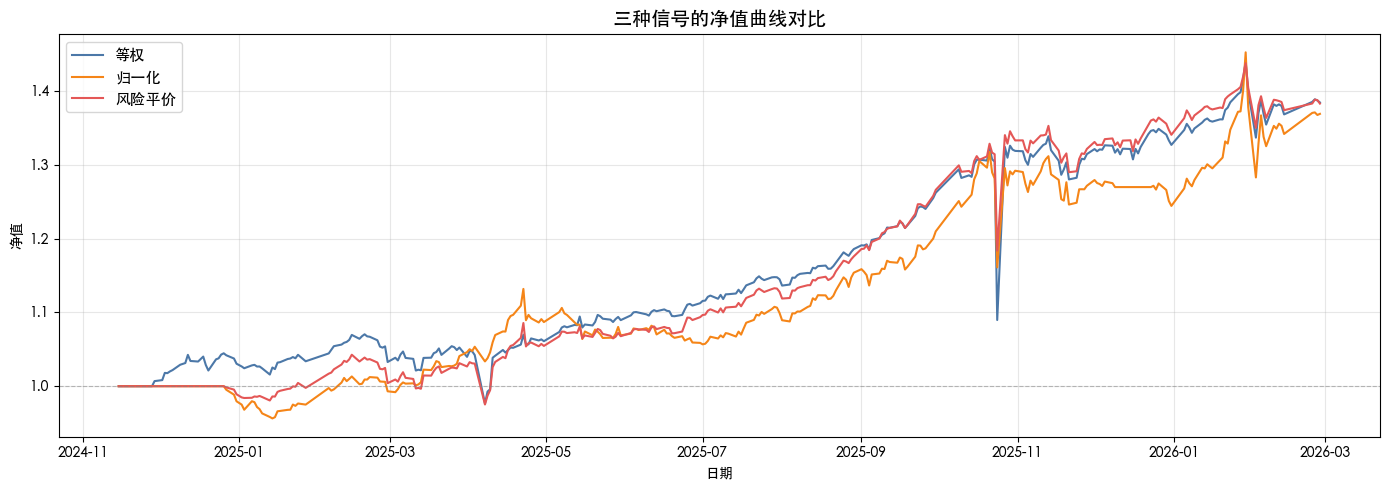

In [8]:
fig, ax = plt.subplots(figsize=(14, 5))
line_style = {
    "等权": {"color": "#4C78A8", "linestyle": "-"},
    "归一化": {"color": "#F58518", "linestyle": "-"},
    "风险平价": {"color": "#E45756", "linestyle": "-"},
}

for label, result in results.items():
    dates = [t for t, _ in result.equity_curve]
    values = [v / INITIAL_CASH for _, v in result.equity_curve]  # 归一化为净值
    ax.plot(dates, values, label=label, linewidth=1.5, **line_style[label])

ax.axhline(y=1.0, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)
ax.set_title("三种信号的净值曲线对比", fontsize=14)
ax.set_ylabel("净值")
ax.set_xlabel("日期")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. 最大回撤曲线对比

净值曲线看起来走势相近？再看回撤曲线——差异立刻显现：

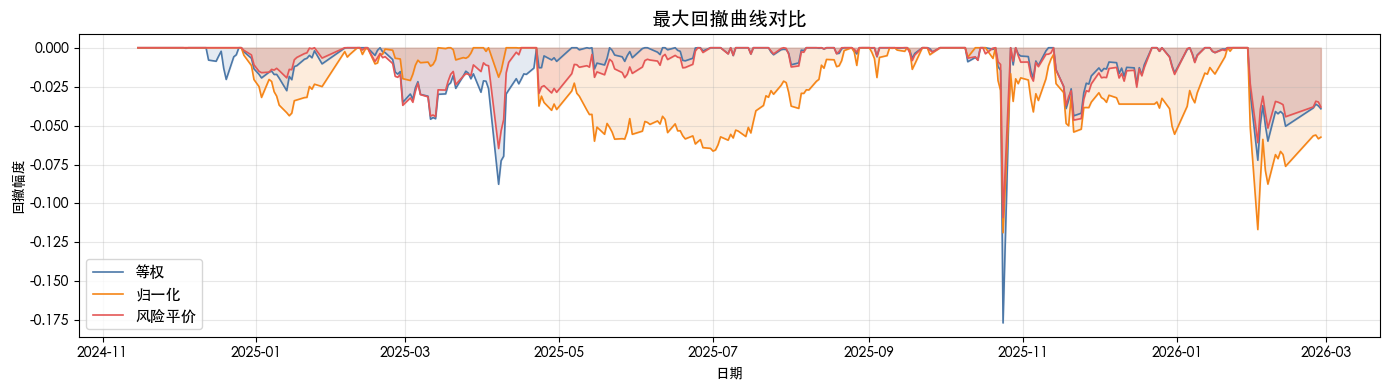

In [9]:
import numpy as np

fig, ax = plt.subplots(figsize=(14, 4))

for label, result in results.items():
    dates = [t for t, _ in result.equity_curve]
    values = np.array([v for _, v in result.equity_curve], dtype=float)
    peak = np.maximum.accumulate(values)
    drawdown = (values - peak) / peak
    ax.fill_between(dates, drawdown, 0, alpha=0.15, **{"color": line_style[label]["color"]})
    ax.plot(dates, drawdown, label=label, linewidth=1.2, color=line_style[label]["color"])

ax.set_title("最大回撤曲线对比", fontsize=14)
ax.set_ylabel("回撤幅度")
ax.set_xlabel("日期")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 关键发现：收益相近，风险迥异

结合净值曲线和回撤曲线，可以看到一个重要现象：

**三种 PortfolioOptimizer 的累计收益率相差不大，但最大回撤和波动率差异显著。**

- **TopNRankingOptimizer** 集中持仓导致回撤最深——当重仓标的大幅下跌时，组合首当其冲
- **EqualWeightOptimizer** 虽然分散，但对高波动资产没有降权，回撤仍然较大
- **RiskParityOptimizer** 自动降低高波动资产的权重，回撤曲线最浅、最平滑

这正是风险平价策略的核心优势：**不靠选对方向赚更多，而是靠控制风险亏更少**。
反映到风险调整指标上，RiskParityOptimizer 的 Sharpe Ratio 和 Calmar Ratio 通常优于另外两种方案。

## 7. 指标对比表

重点关注：年化收益率是否接近？波动率和最大回撤的差距有多大？Sharpe 差异是否显著？

In [10]:
metrics = [
    ("总收益率", lambda r: f"{r.total_return():.2%}"),
    ("年化收益率", lambda r: f"{r.annualized_return():.2%}"),
    ("年化波动率", lambda r: f"{r.annualized_volatility():.2%}"),
    ("Sharpe Ratio", lambda r: f"{r.sharpe_ratio():.2f}"),
    ("Calmar Ratio", lambda r: f"{r.calmar_ratio():.2f}"),
    ("Sortino Ratio", lambda r: f"{r.sortino_ratio():.2f}"),
    ("最大回撤", lambda r: f"{r.max_drawdown():.2%}"),
    ("交易次数", lambda r: f"{len(r.trades)}"),
    ("期末资产", lambda r: f"{r.equity_curve[-1][1]:,.0f}"),
]

header = f"{'指标':>16}" + "".join(f"{label:>14}" for label in results)
print(header)
print("-" * len(header))
for name, fn in metrics:
    vals = "".join(f"{fn(r):>14}" for r in results.values())
    print(f"{name:>16}{vals}")

              指标            等权           归一化          风险平价
----------------------------------------------------------
            总收益率        38.47%        36.93%        38.32%
           年化收益率        26.55%        25.63%        26.46%
           年化波动率        27.41%        20.60%        19.15%
    Sharpe Ratio          1.09          1.35          1.47
    Calmar Ratio          1.50          2.16          2.43
   Sortino Ratio          0.89          1.14          1.24
            最大回撤       -17.68%       -11.88%       -10.91%
            交易次数            93            64            87
            期末资产       138,473       136,928       138,321


## 8. 目标检查

In [11]:
objectives = COMMON["objectives"]
metric_fns = {
    "annualized_return": lambda r: r.annualized_return(),
    "sharpe_ratio": lambda r: r.sharpe_ratio(),
    "max_drawdown": lambda r: r.max_drawdown(),
}

for label, result in results.items():
    checks = []
    for metric_name, bounds in objectives.items():
        actual = metric_fns[metric_name](result)
        passed = True
        if "min" in bounds:
            passed = passed and actual >= bounds["min"]
        if "max" in bounds:
            passed = passed and actual <= bounds["max"]
        tag = "pass" if passed else "FAIL"
        checks.append(f"{tag} {metric_name}")
    print(f"  {label:<8} {'  '.join(checks)}")

  等权       pass annualized_return  pass sharpe_ratio  pass max_drawdown
  归一化      pass annualized_return  pass sharpe_ratio  pass max_drawdown
  风险平价     pass annualized_return  pass sharpe_ratio  pass max_drawdown


---
## 9. 总结：如何选择 PortfolioOptimizer？

### 核心结论

**三种 PortfolioOptimizer 的累计收益率相差不大，但风险特征截然不同。**

回测结果验证了一个经典的资产配置结论：权重分配方法对收益的影响有限，但对波动率、最大回撤和 Sharpe Ratio 的影响巨大。

### 三种优化器的核心区别

| 维度 | EqualWeightOptimizer | TopNRankingOptimizer | RiskParityOptimizer |
|------|-------------|-------------|------------|
| **隐含假设** | 所有资产前景相同 | 强动量资产更优 | 波动率可预测风险 |
| **集中度** | 最分散 | 最集中 | 中等 |
| **换手率** | 最低（权重不变） | 最高（排名变化） | 中等（波动率平滑） |
| **波动率** | 中等 | 最高 | **最低** |
| **最大回撤** | 中等 | 最深 | **最浅** |
| **Sharpe** | 中等 | 受集中度拖累 | **通常最优** |

### 选择建议

- **EqualWeightOptimizer** — 作为 baseline，或在没有好的因子时使用。也适合懒人定投场景
- **TopNRankingOptimizer** — 当你有一个可靠的评分因子（如风险调整动量），并且愿意承受集中持仓带来的高波动和深回撤
- **RiskParityOptimizer** — 追求风险均衡、控制回撤。在收益差不多的前提下，用更小的波动和更浅的回撤换取更高的风险调整收益（Sharpe / Calmar）

### 延伸阅读

- `rotation_strategy` 教程 — 深入 TopNRankingOptimizer 的使用
- `examples/strategies/signal_comparison.py` — 本教程的脚本版本